In [26]:
import pandas as pd
import numpy as np

In [27]:
df = pd.read_csv('/content/mnist_test.csv')
df.shape

(10000, 785)

In [28]:
df.sample(1)

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
2814,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


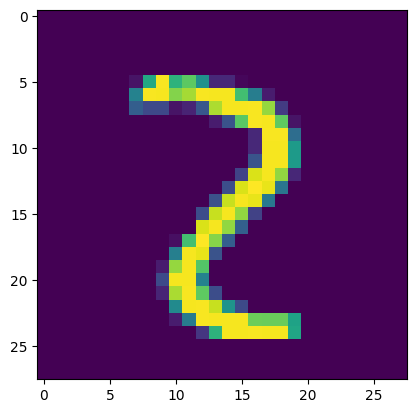

In [29]:
import matplotlib.pyplot as plt
plt.imshow(df.iloc[741,1:].values.reshape(28,28))

In [30]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(df.drop('label',axis=1),df['label'],test_size=0.2,random_state=42)
x_train.shape

(8000, 784)

In [31]:
y_train

,label
9254,9
1561,4
1670,5
6087,5
6669,6
...,...
5734,3
5191,4
5390,2
860,6


In [32]:
from sklearn.preprocessing import StandardScaler
s = StandardScaler()
x_train1 = s.fit_transform(x_train)
x_test1 = s.transform(x_test)

from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(x_train1,y_train)

from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,knn.predict(x_test1)))


0.9185


In [33]:
from sklearn.decomposition import PCA
p = PCA(n_components = 2)
x_train2 = p.fit_transform(x_train1)
x_test2 = p.transform(x_test1)

knn.fit(x_train2,y_train)
print(accuracy_score(y_test,knn.predict(x_test2)))

0.3885


In [34]:
import plotly.express as px

# Create a DataFrame for plotting
pca_df = pd.DataFrame(x_train2, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['label'] = y_train.reset_index(drop=True)

# Create the interactive scatter plot
fig = px.scatter(
    pca_df,
    x='Principal Component 1',
    y='Principal Component 2',
    color='label',
    title='PCA of MNIST Digits (2 Components)',
    labels={'label': 'Digit Label'},
    hover_data={'label': True}
)

fig.show()


In [35]:
p = PCA(n_components = 3)
x_train3 = p.fit_transform(x_train1)
x_test3 = p.transform(x_test1)

knn.fit(x_train3,y_train)
print(accuracy_score(y_test,knn.predict(x_test3)))

0.5105


In [36]:
import plotly.express as px

# Create a DataFrame for 3D plotting
pca_df_3d = pd.DataFrame(x_train3, columns=['Principal Component 1', 'Principal Component 2', 'Principal Component 3'])
pca_df_3d['label'] = y_train.reset_index(drop=True)

# Create the interactive 3D scatter plot
fig_3d = px.scatter_3d(
    pca_df_3d,
    x='Principal Component 1',
    y='Principal Component 2',
    z='Principal Component 3',
    color='label',
    title='3D PCA of MNIST Digits (3 Components)',
    labels={'label': 'Digit Label'},
    hover_data={'label': True},
    height=700 # Adjust height for better viewing
)

fig_3d.show()

OPTIMUM WAY TO FIND NUMBER OF FEATURES

In [37]:
p = PCA(n_components = None)
x_trainn = p.fit_transform(x_train1)
x_testn = p.transform(x_test1)

knn.fit(x_trainn,y_train)
print(accuracy_score(y_test,knn.predict(x_testn)))

0.9185


In [38]:
np.cumsum(p.explained_variance_ratio_)

array([0.06304951, 0.10573428, 0.14652102, 0.17869401, 0.20643952,
       0.23055205, 0.25109332, 0.26995802, 0.28677937, 0.3019896 ,
       0.31685188, 0.33017023, 0.34269062, 0.35472827, 0.36627602,
       0.37728993, 0.38768774, 0.39767138, 0.40710213, 0.41630924,
       0.42536199, 0.4341277 , 0.44272059, 0.45098066, 0.45896723,
       0.46676372, 0.4743301 , 0.48173104, 0.48891897, 0.49584018,
       0.50258321, 0.50913094, 0.51561408, 0.521881  , 0.52802385,
       0.53401432, 0.53988809, 0.54561347, 0.55130402, 0.55693198,
       0.56247338, 0.56790024, 0.57328469, 0.57853895, 0.58360854,
       0.58864926, 0.59364459, 0.5985254 , 0.60338293, 0.60812684,
       0.61278188, 0.61736245, 0.62190551, 0.62642527, 0.63074166,
       0.63504739, 0.63926221, 0.64344998, 0.64759513, 0.65162672,
       0.65561333, 0.65953139, 0.66335323, 0.66710053, 0.67078155,
       0.67443259, 0.67797215, 0.68147744, 0.68492229, 0.68835615,
       0.69176197, 0.69514793, 0.69847314, 0.70175489, 0.70499

In [40]:
p = PCA(n_components = 191)     #most optimal
x_train191 = p.fit_transform(x_train1)
x_test191 = p.transform(x_test1)

knn.fit(x_train191,y_train)
print(accuracy_score(y_test,knn.predict(x_test191)))

0.924
